# Make Segments

## Clean dataset

In [ ]:
from fn.pipeline import *
preprocess_and_save_dataset(
    r"data\machine_translation_docs_info.json",
    r"data\translation_dataset.pkl"
)
preprocess_and_save_dataset(
    r"data\machine_learning_docs_info.json",
    r"data\learning_dataset.pkl"
)

Preprocessing dataset...
Saved processed dataset to data\translation_dataset.pkl
Preprocessing dataset...
Saved processed dataset to data\learning_dataset.pkl


## Train DMR Models

In [ ]:
from fn.pipeline import train_dmr_model
train_dmr_model(
    r"data\translation_dataset.pkl",
    r"models\trans_dmr.bin",
    k_topics=20,
    iterations=500
)


Training DMR model...


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tomotopy\models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


Iter 10: LL per word = -8.626127678157044
Iter 20: LL per word = -8.203918996516403
Iter 30: LL per word = -8.016482590095427
Iter 40: LL per word = -7.904484232761349
Iter 50: LL per word = -7.830706824723538
Iter 60: LL per word = -7.778876399222675
Iter 70: LL per word = -7.744882295360808
Iter 80: LL per word = -7.718567488674233
Iter 90: LL per word = -7.702128203955662
Iter 100: LL per word = -7.687623887951327
Iter 110: LL per word = -7.673707675208469
Iter 120: LL per word = -7.660912802188924
Iter 130: LL per word = -7.651070660724319
Iter 140: LL per word = -7.639822575567618
Iter 150: LL per word = -7.633794491727283
Iter 160: LL per word = -7.628227368592829
Iter 170: LL per word = -7.622914800172089
Iter 180: LL per word = -7.6169367417936344
Iter 190: LL per word = -7.610382586186088
Iter 200: LL per word = -7.603228929523065
Iter 210: LL per word = -7.60010050236667
Iter 220: LL per word = -7.597942057049636
Iter 230: LL per word = -7.594966611042782
Iter 240: LL per wor

In [ ]:
train_dmr_model(
    r"data\learning_dataset.pkl",
    r"models\learning_dmr.bin",
    k_topics=20,
    iterations=500
)

Training DMR model...
Iter 10: LL per word = -9.347022307673194
Iter 20: LL per word = -8.7576984897086
Iter 30: LL per word = -8.520416296407051
Iter 40: LL per word = -8.403763371768223
Iter 50: LL per word = -8.330249914630242
Iter 60: LL per word = -8.28403155987295
Iter 70: LL per word = -8.248859058042898
Iter 80: LL per word = -8.223064748766427
Iter 90: LL per word = -8.204081166239297
Iter 100: LL per word = -8.187974848885093
Iter 110: LL per word = -8.175570697872013
Iter 120: LL per word = -8.165662864454138
Iter 130: LL per word = -8.157326141805013
Iter 140: LL per word = -8.14958524358618
Iter 150: LL per word = -8.143112335801355
Iter 160: LL per word = -8.137728117967836
Iter 170: LL per word = -8.131697152527195
Iter 180: LL per word = -8.125857197093397
Iter 190: LL per word = -8.122590151529435
Iter 200: LL per word = -8.118128618650172
Iter 210: LL per word = -8.112680673770917
Iter 220: LL per word = -8.110453381716805
Iter 230: LL per word = -8.107651186987274
It

## Elbow Method Visualization

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

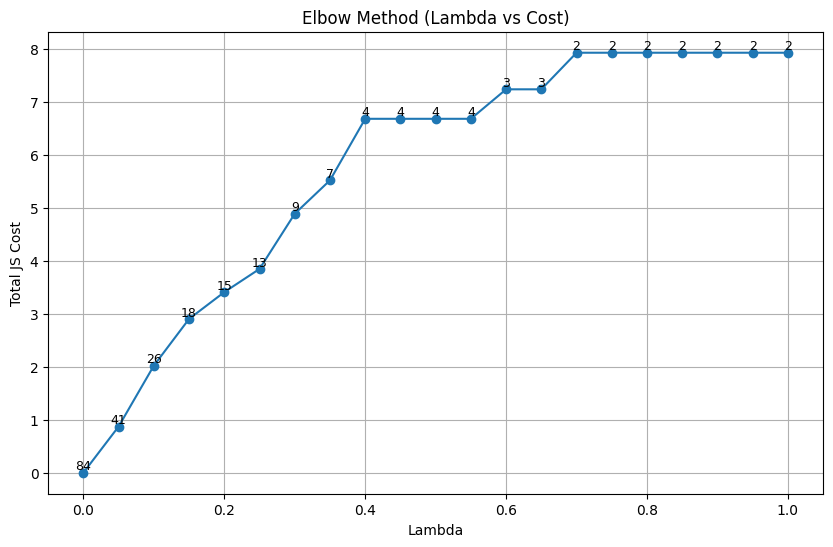

In [1]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\translation_dataset.pkl"
model_path = r"models\trans_dmr.bin"

lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

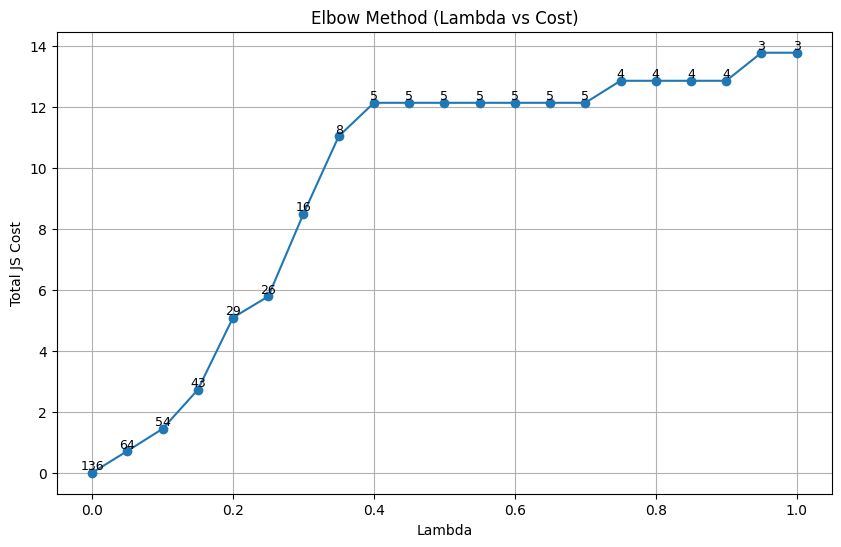

In [2]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\learning_dataset.pkl"
model_path = r"models\learning_dmr.bin"
lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)


## Choose lambda and postprocess segments

### Machine Translation

In [9]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe  # hàm bạn vừa sửa


def run_timeline_and_save():
    dataset_path = r"data\translation_dataset.pkl"
    model_path = r"models\trans_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.25,
        k_topics=20
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

run_timeline_and_save()

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 13


,start_year,end_year,period,num_docs,topic,topic_certainty
0,1819,1852,2,2,7,0.616616
1,1899,1899,1,1,5,0.457940
2,1933,1933,1,2,19,0.430895
3,1941,1941,1,2,7,0.942638
4,1942,1942,1,1,3,0.825631
5,1943,1947,2,3,19,0.331714
6,1949,1949,1,1,10,0.324307
7,1950,1950,1,1,3,0.422550
8,1951,1951,1,3,19,0.687114
9,1952,1952,1,1,7,0.735479


In [6]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe  # hàm bạn vừa sửa


def run_timeline_and_save():
    dataset_path = r"data\learning_dataset.pkl"
    model_path = r"models\learning_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.25,
        k_topics=20
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

run_timeline_and_save()

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 26


,start_year,end_year,period,num_docs,topic,topic_certainty
0,1744,1744,1,1,6,0.530634
1,1801,1801,1,1,12,0.353838
2,1819,1842,2,2,17,0.326957
3,1852,1852,1,1,2,0.591658
4,1856,1856,1,1,17,0.554462
5,1859,1859,1,1,14,0.333547
6,1865,1888,3,4,17,0.233645
7,1891,1892,2,2,16,0.237847
8,1893,1898,3,4,17,0.327757
9,1899,1899,1,2,6,0.241781
